In [3]:
import pandas as pd


In [4]:
df = pd.read_csv("Retail_Sales.csv")
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 11)


In [6]:
print("Column names:")
print(df.columns.tolist())

Column names:
['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender', 'age', 'category', 'quantiy', 'price_per_unit', 'cogs', 'total_sale']


In [7]:
print("Data Types")
print(df.dtypes)

Data Types
transactions_id      int64
sale_date           object
sale_time           object
customer_id          int64
gender              object
age                float64
category            object
quantiy            float64
price_per_unit     float64
cogs               float64
total_sale         float64
dtype: object


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
transactions_id     0
sale_date           0
sale_time           0
customer_id         0
gender              0
age                10
category            0
quantiy             3
price_per_unit      3
cogs                3
total_sale          3
dtype: int64


In [9]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


In [10]:
df[df.isnull().any(axis=1)]

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sale
24,432,2022-03-10,11:31:00,17,Female,NaN,Electronics,2.0,500.0,190.00,1000.0
25,1367,2022-04-15,11:38:00,16,Female,NaN,Electronics,1.0,50.0,15.50,50.0
26,1391,2022-03-01,11:29:00,130,Male,NaN,Beauty,2.0,25.0,9.25,50.0
27,1432,2022-12-25,06:24:00,67,Female,NaN,Electronics,2.0,500.0,245.00,1000.0
28,150,2022-04-13,08:25:00,89,Female,NaN,Electronics,4.0,30.0,16.20,120.0
29,845,2022-10-27,10:12:00,25,Male,NaN,Clothing,1.0,500.0,145.00,500.0
30,1150,2022-08-22,10:04:00,77,Female,NaN,Electronics,4.0,30.0,10.20,120.0
31,1845,2022-05-24,07:06:00,94,Male,NaN,Clothing,1.0,500.0,185.00,500.0
32,797,2022-09-16,06:38:00,116,Male,NaN,Clothing,3.0,25.0,10.75,75.0
33,921,2022-09-28,09:34:00,101,Male,NaN,Electronics,3.0,25.0,8.00,75.0


In [11]:
df.isnull().sum().sum()

np.int64(22)

In [12]:
df['age'].median()

42.0

In [13]:
df['age'].describe()

,age
count,1990.000000
mean,41.343216
std,13.668167
min,18.000000
25%,29.000000
50%,42.000000
75%,53.000000
max,64.000000


In [14]:
# Filling missing age values with the median age
df['age'] = df['age'].fillna(df['age'].median())

#Removing rows where all Sales-related info is missing
df = df.dropna(subset=['quantiy', 'price_per_unit', 'cogs', 'total_sale'])

#Checking all missing values again
print(df.isnull().sum())

transactions_id    0
sale_date          0
sale_time          0
customer_id        0
gender             0
age                0
category           0
quantiy            0
price_per_unit     0
cogs               0
total_sale         0
dtype: int64


In [15]:
#Converting sale_date to datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])

#Changinging the misspelled column
df.rename(columns={'quantiy': 'quantity'}, inplace=True)

#Check the changes
print(df.dtypes)
print(df.columns.tolist())

transactions_id             int64
sale_date          datetime64[ns]
sale_time                  object
customer_id                 int64
gender                     object
age                       float64
category                   object
quantity                  float64
price_per_unit            float64
cogs                      float64
total_sale                float64
dtype: object
['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender', 'age', 'category', 'quantity', 'price_per_unit', 'cogs', 'total_sale']


In [16]:
df.describe()

,transactions_id,sale_date,customer_id,age,quantity,price_per_unit,cogs,total_sale
count,1997.000000,1997,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000
mean,1000.676014,2023-02-17 07:34:16.885327872,66.319479,41.354532,2.512769,180.117677,95.023886,456.544817
min,1.000000,2022-01-01 00:00:00,1.000000,18.000000,1.000000,25.000000,6.250000,25.000000
25%,500.000000,2022-09-23 00:00:00,24.000000,29.000000,1.000000,30.000000,13.000000,60.000000
50%,1001.000000,2023-01-14 00:00:00,69.000000,42.000000,3.000000,50.000000,27.500000,150.000000
75%,1501.000000,2023-09-14 00:00:00,102.000000,53.000000,4.000000,300.000000,147.000000,900.000000
max,2000.000000,2023-12-31 00:00:00,155.000000,64.000000,4.000000,500.000000,620.000000,2000.000000
std,577.833658,NaN,44.939785,13.628462,1.132708,189.685225,121.898695,560.101381


In [17]:
df.describe(include='object')

,sale_time,gender,category
count,1997,1997,1997
unique,764,2,3
top,17:12:00,Female,Clothing
freq,9,1017,701


In [18]:
df['month'] = df['sale_date'].dt.to_period('M')

In [19]:
monthly_sales = df.groupby('month')['total_sale'].sum()

monthly_sales

,total_sale
month,
2022-01,22635.0
2022-02,16110.0
2022-03,24505.0
2022-04,28705.0
2022-05,24980.0
2022-06,20700.0
2022-07,22195.0
2022-08,21195.0
2022-09,61770.0


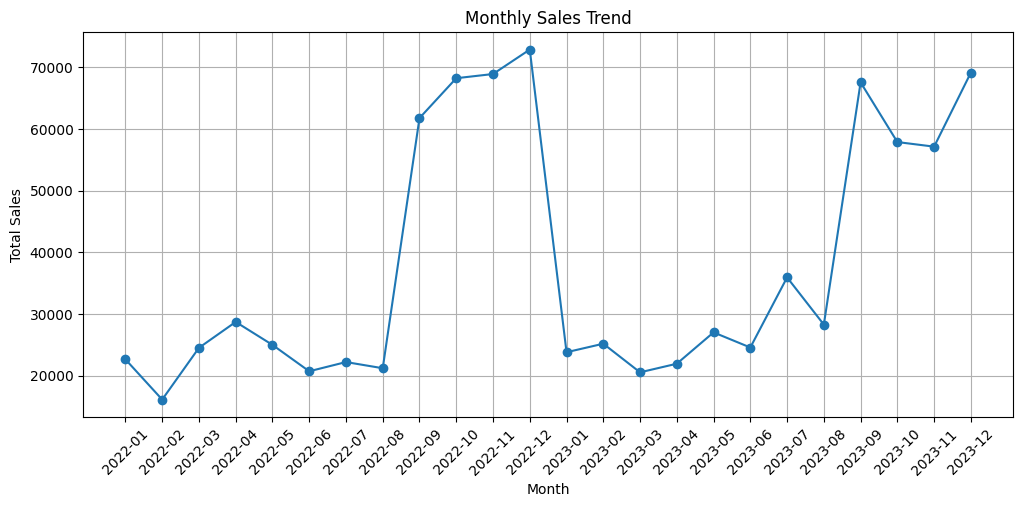

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Monthly Sales Interpretation:Sales increased throughout 2022 and 2023, with the highest sales of ₹72,880 in December 2022. A similar rise was also observed in September-December 2023, showing a possible seasonal pattern.

In [21]:
df['quarter'] = df['sale_date'].dt.to_period('Q')

In [22]:
quarterly_sales = df.groupby('quarter')['total_sale'].sum()
quarterly_sales

,total_sale
quarter,
2022Q1,63250.0
2022Q2,74385.0
2022Q3,105160.0
2022Q4,210030.0
2023Q1,69490.0
2023Q2,73490.0
2023Q3,131755.0
2023Q4,184160.0


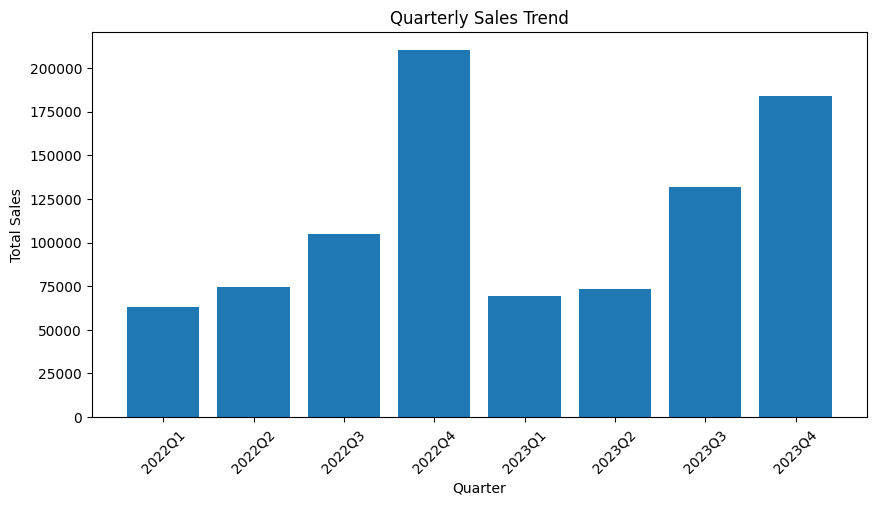

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    quarterly_sales.index.astype(str),
    quarterly_sales.values
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

Quarterly Sales Interpretation: Sales increased mostly during Q3 and Q4 in both years. Q4 2022 shows the highest sales of ₹210,030, and then Q4 2023 with ₹184,160. The repeated increase in sales during the second half of each year suggests a possible seasonal pattern.

In [24]:
gender_counts = df['gender'].value_counts()
print(gender_counts)

gender
Female    1017
Male       980
Name: count, dtype: int64


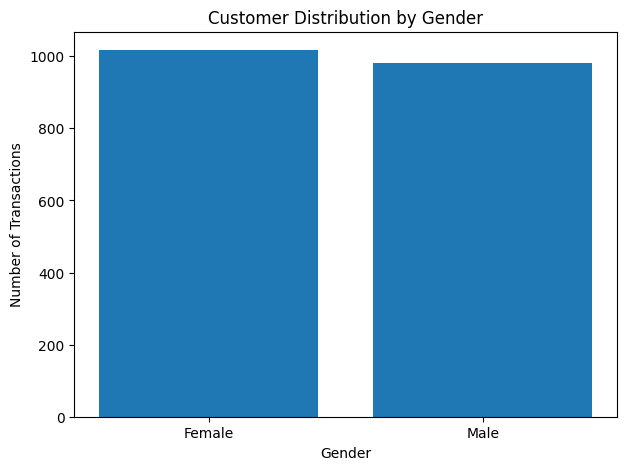

In [25]:
plt.figure(figsize=(7, 5))

plt.bar(gender_counts.index, gender_counts.values)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')

plt.show()

Gender Interpretation: Female customers made slightly more transactions(1,017) than male customers (980), showing very small difference between them.

In [26]:
age_bins = [17,25, 35, 45, 55, 65]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-64']

df['age_group'] = pd.cut(
    df['age'],
    bins=age_bins,
    labels=age_labels
)

age_group_counts = df['age_group'].value_counts().sort_index()

print(age_group_counts)

age_group
18-25    336
26-35    409
36-45    413
46-55    455
56-64    384
Name: count, dtype: int64


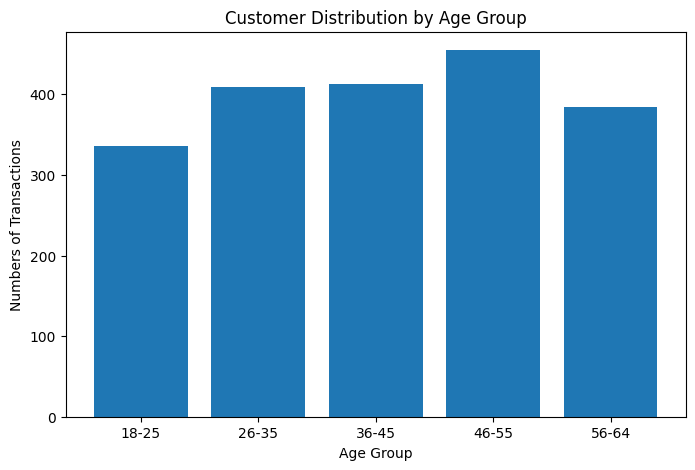

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(age_group_counts.index, age_group_counts.values)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Numbers of Transactions')
plt.show()

Age Group Interpretation: The 46-55 age group had the highest number of transactions (455), while the 18-25 age group had the lowest(336).

In [28]:
category_counts = df['category'].value_counts()
print(category_counts)

category
Clothing       701
Electronics    684
Beauty         612
Name: count, dtype: int64


In [29]:
category_sales = df.groupby('category')['total_sale'].sum().sort_values(ascending=False)
print(category_sales)

category
Electronics    313810.0
Clothing       311070.0
Beauty         286840.0
Name: total_sale, dtype: float64


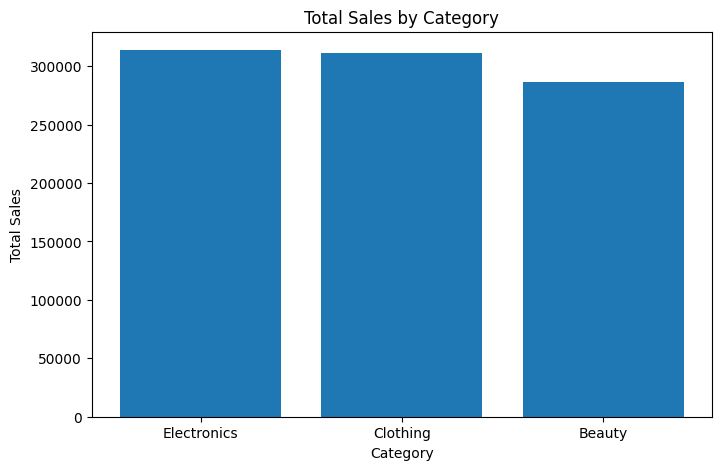

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values)

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

Category Interpretation: Clothing shows the highest number of transactions with 701, while Electronics have the highest total sales of ₹313,810. Even though Clothing had more transactions than Electronics, Electronics had slightly higher revenue. But Beauty had the lowest transaction and revenue among these three categories

In [31]:
df.columns

Index(['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender',
       'age', 'category', 'quantity', 'price_per_unit', 'cogs', 'total_sale',
       'month', 'quarter', 'age_group'],
      dtype='object')

LIMITATION: The selected dataset does not contain a product name or product id column. So, top-10 product analysis cannot be done. That's why category level transaction and revenue were analyzed.

In [32]:
correlation_matrix = df[
    ['age', 'quantity', 'price_per_unit', 'cogs', 'total_sale']
].corr()

correlation_matrix

,age,quantity,price_per_unit,cogs,total_sale
age,1.000000,-0.023628,-0.041957,-0.034301,-0.061936
quantity,-0.023628,1.000000,0.018397,0.041463,0.374721
price_per_unit,-0.041957,0.018397,1.000000,0.802198,0.851825
cogs,-0.034301,0.041463,0.802198,1.000000,0.709780
total_sale,-0.061936,0.374721,0.851825,0.709780,1.000000


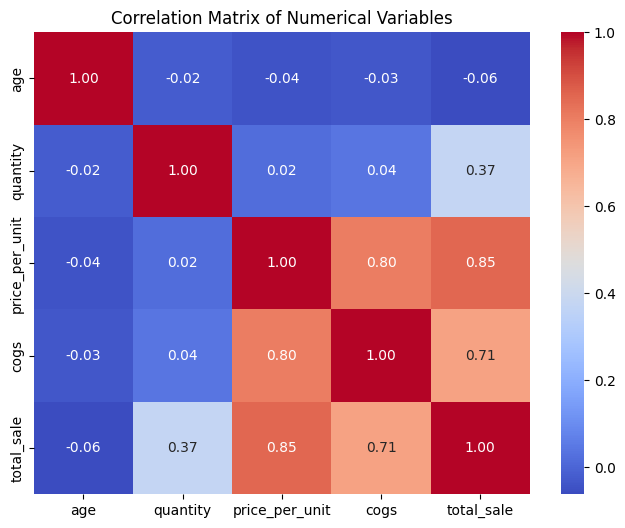

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

Correlation Interpretation: Price per unit has the strongest positive correlation with total sales(0.85), while quantity has a moderate positive correlation(0.37).Age has very little correlation.

In [34]:
#Average Sales By Gender (Additional visualization)

avg_sales_gender = df.groupby('gender')['total_sale'].mean()

print(avg_sales_gender)

gender
Female    457.620452
Male      455.428571
Name: total_sale, dtype: float64


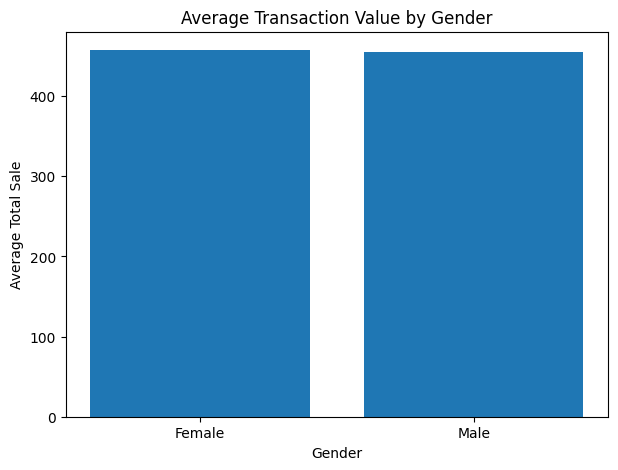

In [35]:
plt.figure(figsize=(7, 5))

plt.bar(avg_sales_gender.index, avg_sales_gender.values)

plt.title('Average Transaction Value by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Total Sale')
plt.show()

AVG Transaction Value By Gender:Female customers had an average transaction value 0f 457.62, slightly higher than male customers with an average of 455.43. The difference is very small among genders.

In [36]:
#Mode
df.select_dtypes(include='number').mode().iloc[0]

,0
transactions_id,1.0
customer_id,1.0
age,42.0
quantity,4.0
price_per_unit,50.0
cogs,13.5
total_sale,50.0


Conclusion

The analysis shows that sales are stronger during the later months of the year, particularly in Q4. Electronics had the highest revenue among the categories, while custonmers aged 46-55 recorded the highest number of transactions. lastly, price per unit showed the strongest positive relationship with total sales.



Bussiness Recommendations

1. Increase inventory and marketing efforts during the high performing months.
2. Focus promotions on the Beauty category to increase the revenue.
3. Target the 46-55 age group with suitable offers and campaigns.